In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from utils import get_storey_mid

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_PATH = curr_dir.parent.parent/ "data" / "geocode_final.csv"
POST_CUTOFF = pd.Timestamp("2016-01-01")   # user: rumours started 2015-2016
OUT_DIR = "."


Is Yishun cheapest town? Rumours of it's bad reputation seems to start aorund 2015

Two seperate methods to answer

1) By ranking recent data controlled for flat_type, size, storey, lease, flat_model
2) Hedonic (OLS) method to control 



In [2]:
scale_data_prices =  pd.read_csv(curr_dir.parent.parent/ "data" / "geocoded_final_scaled_2026_with_poi.csv")

C:\Users\zheng\AppData\Local\Temp\ipykernel_23620\1620231301.py:1: DtypeWarning: Columns (0: onemap_postal) have mixed types. Specify dtype option on import or set low_memory=False.
  scale_data_prices =  pd.read_csv(curr_dir.parent.parent/ "data" / "geocoded_final_scaled_2026_with_poi.csv")


In [3]:
subset_data = scale_data_prices[["town", "flat_type", "storey_range", "floor_area_sqm", "flat_model", "lease_commence_date", "flat_age_years", "resale_price", "resale_price_2026q2"]]
subset_data["rescaled_price_per_sqm"] = subset_data["resale_price_2026q2"]/ subset_data["floor_area_sqm"]


Control for floor range, floor area, flat_model, flat_age_years
Yishun only has 1-18 floors

In [4]:
subset_data[subset_data.town=="YISHUN"].storey_range.value_counts().sort_index()

storey_range
01 TO 03    1319
04 TO 06    1654
07 TO 09    1489
10 TO 12    1365
13 TO 15     315
16 TO 18       8
Name: count, dtype: int64

subset_data[subset_data.town=="YISHUN"].floor_area_sqm.plot(kind="hist", bins=50)

<Axes: ylabel='Frequency'>

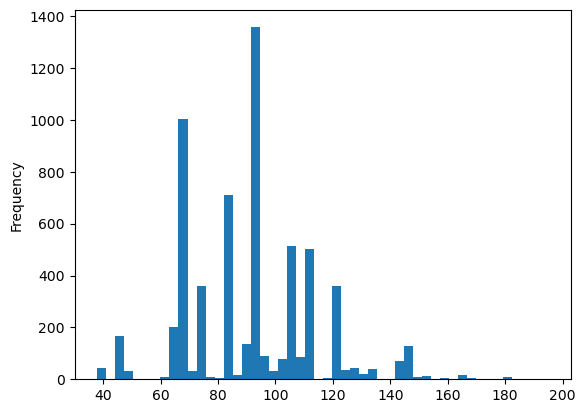

In [5]:
subset_data[subset_data.town=="YISHUN"].floor_area_sqm.plot(kind="hist", bins=50)

<Axes: ylabel='Frequency'>

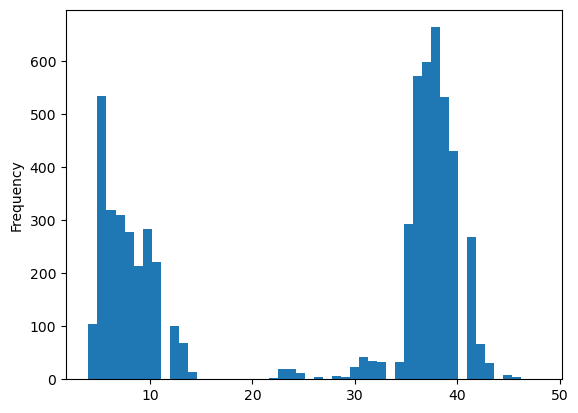

In [6]:
subset_data[subset_data.town=="YISHUN"].flat_age_years.plot(kind="hist", bins=50)

In [7]:
yishun_flat_model = subset_data[subset_data.town=="YISHUN"].flat_model.unique()
yishun_min_floor_area = subset_data[subset_data.town=="YISHUN"].floor_area_sqm.min()
yishun_max_floor_area = subset_data[subset_data.town=="YISHUN"].floor_area_sqm.max()
yishun_flat_type = subset_data[subset_data.town=="YISHUN"].flat_type.unique()
yishun_storey_range = subset_data[subset_data.town=="YISHUN"].storey_range.unique()
yishun_min_flat_age = subset_data[subset_data.town=="YISHUN"].flat_age_years.min()
yishun_max_flat_age = subset_data[subset_data.town=="YISHUN"].flat_age_years.max()


## Restrict comparison set to Yishun's own range

Only keep rows whose `flat_type`, `flat_model`, and `storey_range` actually occur in Yishun,
so other towns aren't compared on flat characteristics Yishun doesn't have (e.g. high-rise
31-33 floors, or flat models Yishun never built).

Then bin `storey_range` into low/mid/high and `flat_age_years` into 5-year-ish buckets so the
groupby cells aren't fragmented across dozens of individual floor bands / ages.


In [8]:
yishun_subset = subset_data[
    subset_data["flat_type"].isin(yishun_flat_type)
    & subset_data["flat_model"].isin(yishun_flat_model)
    & subset_data["storey_range"].isin(yishun_storey_range)
    & subset_data["floor_area_sqm"].between(yishun_min_floor_area, yishun_max_floor_area)
    & subset_data["flat_age_years"].between(yishun_min_flat_age, yishun_max_flat_age)
].copy()

print(f"rows before restricting to Yishun's range: {len(subset_data):,}")
print(f"rows after restricting to Yishun's range:  {len(yishun_subset):,}")
print(f"towns retained: {yishun_subset['town'].nunique()}")


rows before restricting to Yishun's range: 90,914
rows after restricting to Yishun's range:  78,886
towns retained: 26


In [9]:
def bin_storey(storey_range):
    low_floor = int(storey_range.split(" TO ")[0])
    if low_floor <= 6:
        return "low (01-06)"
    elif low_floor <= 9:
        return "mid (07-09)"
    else:
        return "high (10+)"

yishun_subset["storey_binned"] = yishun_subset["storey_range"].apply(bin_storey)
yishun_subset["storey_binned"].value_counts()


storey_binned
low (01-06)    33386
high (10+)     27942
mid (07-09)    17558
Name: count, dtype: int64

In [10]:
age_bins = [-np.inf, 5, 10, 20, 30, 40, np.inf]
age_labels = ["<5", "5-10", "10-20", "20-30", "30-40", "40+"]
yishun_subset["flat_age_binned"] = pd.cut(
    yishun_subset["flat_age_years"], bins=age_bins, labels=age_labels, right=False
)
yishun_subset["flat_age_binned"].value_counts().sort_index()


flat_age_binned
<5        2843
5-10     16902
10-20     8136
20-30    17698
30-40    18250
40+      15057
Name: count, dtype: int64

In [11]:
group_cols = ["flat_type", "storey_binned", "flat_model", "flat_age_binned", "town"]
median_psf_by_group = (
    yishun_subset.groupby(group_cols, observed=True)["rescaled_price_per_sqm"]
    .median()
    .reset_index()
)
median_psf_by_group


,flat_type,storey_binned,flat_model,flat_age_binned,town,rescaled_price_per_sqm
0,2 ROOM,high (10+),2-room,<5,BUKIT BATOK,8382.905357
1,2 ROOM,high (10+),2-room,<5,HOUGANG,8414.846177
2,2 ROOM,high (10+),2-room,<5,SENGKANG,8702.495042
3,2 ROOM,high (10+),2-room,<5,YISHUN,8087.759429
4,2 ROOM,high (10+),2-room,5-10,BEDOK,10883.467888
...,...,...,...,...,...,...
2466,MULTI-GENERATION,high (10+),Multi Generation,30-40,YISHUN,8073.874424
2467,MULTI-GENERATION,low (01-06),Multi Generation,30-40,TAMPINES,6603.700939
2468,MULTI-GENERATION,low (01-06),Multi Generation,30-40,YISHUN,6568.503484
2469,MULTI-GENERATION,mid (07-09),Multi Generation,30-40,BISHAN,8069.857571


<Axes: xlabel='resale_price_2026q2', ylabel='Count'>

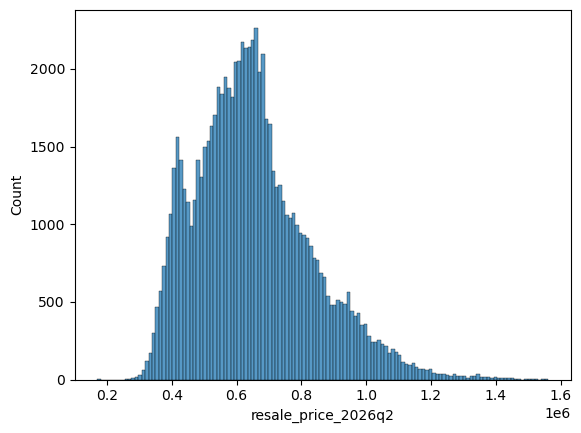

In [21]:
import seaborn as sns
sns.histplot(yishun_subset.resale_price_2026q2)

<Axes: xlabel='resale_price_2026q2', ylabel='Count'>

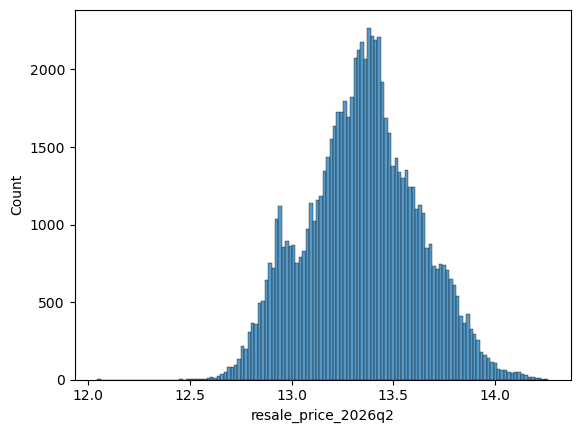

In [22]:
import seaborn as sns
sns.histplot(np.log(yishun_subset.resale_price_2026q2))

In [12]:
cell_cols = ["flat_type", "storey_binned", "flat_model", "flat_age_binned"]

# only keep cells that actually contain YISHUN -- otherwise we're comparing
# Yishun to combinations it never even competes in
cells_with_yishun = median_psf_by_group.groupby(cell_cols, observed=True).filter(
    lambda g: (g["town"] == "YISHUN").any()
)

# of those, only cells with >=2 towns present have a meaningful "cheapest" comparison
comparable_cells = cells_with_yishun.groupby(cell_cols, observed=True).filter(lambda g: g["town"].nunique() > 1)

cheapest_per_cell = comparable_cells.loc[
    comparable_cells.groupby(cell_cols, observed=True)["rescaled_price_per_sqm"].idxmin()
]

n_comparable_cells = cheapest_per_cell.shape[0]
n_yishun_cheapest = (cheapest_per_cell["town"] == "YISHUN").sum()

print(f"Total comparable cells containing Yishun with >=2 towns present: {len(comparable_cells)}")
print(f"cells containing Yishun with >=2 towns present: {n_comparable_cells}")
print(f"cells where YISHUN has the lowest median $/sqm: {n_yishun_cheapest}")
print(f"share: {n_yishun_cheapest / n_comparable_cells:.1%}")

cheapest_per_cell["town"].value_counts()


Total comparable cells containing Yishun with >=2 towns present: 1977
cells containing Yishun with >=2 towns present: 141
cells where YISHUN has the lowest median $/sqm: 13
share: 9.2%


town
JURONG WEST      48
CHOA CHU KANG    27
JURONG EAST      15
YISHUN           13
WOODLANDS        13
BUKIT PANJANG    10
SEMBAWANG         8
BUKIT BATOK       4
BEDOK             2
TAMPINES          1
Name: count, dtype: int64

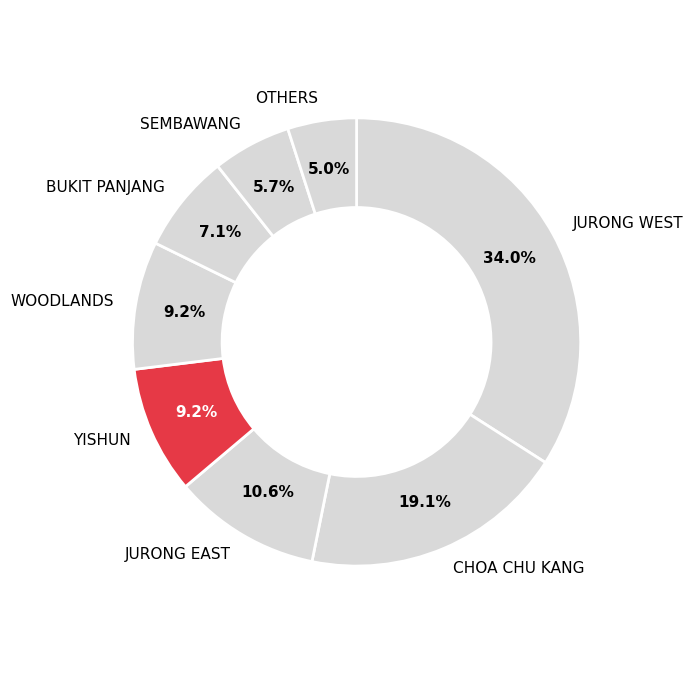

In [13]:
town_counts = cheapest_per_cell["town"].value_counts()
top_towns = town_counts.iloc[:7]
others_n = town_counts.iloc[7:].sum()
sizes = list(top_towns.values) + [others_n]
labels = list(top_towns.index) + ["OTHERS"]
colors = ["#D9D9D9"] * len(labels)
colors[labels.index("YISHUN")] = "#E63946"
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for label, autotext in zip(labels, autotexts):
    autotext.set_fontweight("bold")
    autotext.set_color("white" if label == "YISHUN" else "black")

ax.axis("equal")
fig.tight_layout()
fig.savefig("yishun_cheapest_cell_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
scale_data_prices

,Unnamed: 0,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,onemap_searchval,onemap_blk_no,onemap_road_name,onemap_building,onemap_address,onemap_postal,onemap_x,onemap_y,latitude,longitude,Town,Region,Area (km2),Population (2025)[8],Population density (/km2),Subzones,town_cleaned,Year,Quarter,Index,resale_price_2026q2,school_name,dist_to_school,Mrt Name,dist_to_MRT,Mall Name,dist_to_Mall,popular school name,dist_to_pop_school
0,0,2023-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1977,46,53,380000.0,Resale flat prices based on registration date ...,ANG MO KIO GROVE,220,ANG MO KIO AVENUE 1,ANG MO KIO GROVE,220 ANG MO KIO AVENUE 1 ANG MO KIO GROVE SINGA...,560220,28801.30810,38625.33687,1.365588,103.840519,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,424.488420,TECK GHEE,356.013096,Broadway Plaza,926.335403,AI TONG SCHOOL,1001.330795
1,1,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,269.253824,MAYFLOWER,419.340783,Broadway Plaza,1002.765762,AI TONG SCHOOL,945.184788
2,2,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,269.253824,MAYFLOWER,419.340783,Broadway Plaza,1002.765762,AI TONG SCHOOL,945.184788
3,3,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,16 TO 18,123.0,Standard,1977,46,53,682888.0,Resale flat prices based on registration date ...,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,797358.281106,TECK GHEE PRIMARY SCHOOL,585.345627,TECK GHEE,185.014669,AMK Hub,493.467905,AI TONG SCHOOL,1526.567786
4,4,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,04 TO 06,123.0,Standard,1977,46,53,695000.0,Resale flat prices based on registration date ...,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,811500.576037,TECK GHEE PRIMARY SCHOOL,585.345627,TECK GHEE,185.014669,AMK Hub,493.467905,AI TONG SCHOOL,1526.567786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90909,90909,2026-06-01,YISHUN,5 ROOM,757,YISHUN ST 72,757 YISHUN ST 72,10 TO 12,122.0,Improved,1986,40,59,688888.0,Resale flat prices based on registration date ...,757 YISHUN STREET 72 SINGAPORE 760757,757,YISHUN STREET 72,NIL,757 YISHUN STREET 72 SINGAPORE 760757,760757,28107.51679,45361.82800,1.426511,103.834285,Yishun,North,21.24,"228,730","10,769",9.0,YISHUN,2026,2,202.7,688888.000000,JIEMIN PRIMARY SCHOOL,448.782793,YISHUN,358.482100,Northpoint City,304.010055,AI TONG SCHOOL,7291.266684
90910,90910,2026-06-01,YISHUN,4 ROOM,829,YISHUN ST 81,829 YISHUN ST 81,04 TO 06,103.0,Model A,1988,38,61,575000.0,Resale flat p

## Try OLS method to see yishun coefficient 

In [24]:
scale_data_prices.head()

,Unnamed: 0,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,onemap_searchval,onemap_blk_no,onemap_road_name,onemap_building,onemap_address,onemap_postal,onemap_x,onemap_y,latitude,longitude,Town,Region,Area (km2),Population (2025)[8],Population density (/km2),Subzones,town_cleaned,Year,Quarter,Index,resale_price_2026q2,school_name,dist_to_school,Mrt Name,dist_to_MRT,Mall Name,dist_to_Mall,popular school name,dist_to_pop_school,mid_floor
0,0,2023-01-01,ANG MO KIO,3 ROOM,220,ANG MO KIO AVE 1,220 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1977,46,53,380000.0,Resale flat prices based on registration date ...,ANG MO KIO GROVE,220,ANG MO KIO AVENUE 1,ANG MO KIO GROVE,220 ANG MO KIO AVENUE 1 ANG MO KIO GROVE SINGA...,560220,28801.30810,38625.33687,1.365588,103.840519,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,424.488420,TECK GHEE,356.013096,Broadway Plaza,926.335403,AI TONG SCHOOL,1001.330795,5.0
1,1,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,04 TO 06,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,269.253824,MAYFLOWER,419.340783,Broadway Plaza,1002.765762,AI TONG SCHOOL,945.184788,5.0
2,2,2023-01-01,ANG MO KIO,3 ROOM,225,ANG MO KIO AVE 1,225 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1978,45,54,380000.0,Resale flat prices based on registration date ...,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,225,ANG MO KIO AVENUE 1,NIL,225 ANG MO KIO AVENUE 1 SINGAPORE 560225,560225,28537.68004,38825.23263,1.367396,103.838150,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,443698.156682,ANG MO KIO PRIMARY SCHOOL,269.253824,MAYFLOWER,419.340783,Broadway Plaza,1002.765762,AI TONG SCHOOL,945.184788,8.0
3,3,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,16 TO 18,123.0,Standard,1977,46,53,682888.0,Resale flat prices based on registration date ...,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,797358.281106,TECK GHEE PRIMARY SCHOOL,585.345627,TECK GHEE,185.014669,AMK Hub,493.467905,AI TONG SCHOOL,1526.567786,17.0
4,4,2023-01-01,ANG MO KIO,5 ROOM,306,ANG MO KIO AVE 1,306 ANG MO KIO AVE 1,04 TO 06,123.0,Standard,1977,46,53,695000.0,Resale flat prices based on registration date ...,TECK GHEE VISTA,306,ANG MO KIO AVENUE 1,TECK GHEE VISTA,306 ANG MO KIO AVENUE 1 TECK GHEE VISTA SINGAP...,560306,29383.53183,38640.50861,1.365726,103.845751,Ang Mo Kio,North-East,13.94,"158,720","11,386",12.0,ANG MO KIO,2023,1,173.6,811500.576037,TECK GHEE PRIMARY SCHOOL,585.345627,TECK GHEE,185.014669,AMK Hub,493.467905,AI TONG SCHOOL,1526.567786,5.0


In [16]:
scale_data_prices["mid_floor"] = scale_data_prices["storey_range"].apply(get_storey_mid)
hedonic_recent = smf.ols(
    "resale_price_2026q2 ~ C(town) + C(flat_type) + C(flat_model) + mid_floor + flat_age_years + floor_area_sqm + dist_to_MRT + dist_to_Mall + dist_to_school + dist_to_pop_school",
    data=scale_data_prices
).fit(cov_type="cluster", cov_kwds={"groups": scale_data_prices["town"]})

In [17]:
town_effects = hedonic_recent.params.filter(like="C(town)").sort_values()

In [18]:
town_effects

C(town)[T.CHOA CHU KANG]     -182141.576716
C(town)[T.PUNGGOL]           -137340.717797
C(town)[T.SEMBAWANG]         -130464.392970
C(town)[T.JURONG WEST]       -128793.613388
C(town)[T.SENGKANG]          -124703.521683
C(town)[T.WOODLANDS]         -121091.215586
C(town)[T.BUKIT BATOK]       -112416.318021
C(town)[T.BUKIT PANJANG]     -105444.407535
C(town)[T.PASIR RIS]          -92652.137249
C(town)[T.JURONG EAST]        -91868.984236
C(town)[T.YISHUN]             -78719.159426
C(town)[T.HOUGANG]            -75434.743754
C(town)[T.TAMPINES]           -43775.005888
C(town)[T.BEDOK]              -12249.197780
C(town)[T.SERANGOON]           20696.412427
C(town)[T.CLEMENTI]            24242.908282
C(town)[T.GEYLANG]             44777.285877
C(town)[T.KALLANG/WHAMPOA]     73115.556290
C(town)[T.CENTRAL AREA]        80667.519596
C(town)[T.TOA PAYOH]           85778.658859
C(town)[T.QUEENSTOWN]         114360.800098
C(town)[T.MARINE PARADE]      115655.964050
C(town)[T.BISHAN]             11

In [19]:
hedonic_recent.summary()

c:\Users\zheng\anaconda3\envs\nus_odi\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 26
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     resale_price_2026q2   R-squared:                       0.899
Model:                             OLS   Adj. R-squared:                  0.899
Method:                  Least Squares   F-statistic:                -2.004e+13
Date:                 Tue, 21 Jul 2026   Prob (F-statistic):               1.00
Time:                         09:04:00   Log-Likelihood:            -1.1356e+06
No. Observations:                90914   AIC:                         2.271e+06
Df Residuals:                    90856   BIC:                         2.272e+06
Df Model:                           57                                         
Covariance Type:               cluster                                         
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                4.139e+05   5.46e+04      7.586      0.000    3.07e+05    5.21e+05
C(town)[T.BEDOK]                        -1.225e+04   8204.632     -1.493      0.135   -2.83e+04    3831.586
C(town)[T.BISHAN]                        1.167e+05   9727.094     11.993      0.000    9.76e+04    1.36e+05
C(town)[T.BUKIT BATOK]                  -1.124e+05   1.69e+04     -6.649      0.000   -1.46e+05   -7.93e+04
C(town)[T.BUKIT MERAH]                   1.276e+05   1.52e+04      8.403      0.000    9.78e+04    1.57e+05
C(town)[T.BUKIT PANJANG]                -1.054e+05   2.37e+04     -4.457      0.000   -1.52e+05   -5.91e+04
C(town)[T.BUKIT TIMAH]                   2.341e+05   1.62e+04     14.482      0.000    2.02e+05    2.66e+05
C(town)[T.CENTRAL AREA]                  8.067e+04   1.28e+04      6.284      0.000    5.55e+04    1.06e+05
C(town)[T.CHOA CHU KANG]                -1.821e+05   3.33e+04     -5.474      0.000   -2.47e+05   -1.17e+05
C(town)[T.CLEMENTI]                      2.424e+04   7218.162      3.359      0.001    1.01e+04    3.84e+04
C(town)[T.GEYLANG]                       4.478e+04   9577.870      4.675      0.000     2.6e+04    6.35e+04
C(town)[T.HOUGANG]                      -7.543e+04    1.2e+04     -6.268      0.000    -9.9e+04   -5.18e+04
C(town)[T.JURONG EAST]                  -9.187e+04   1.79e+04     -5.135      0.000   -1.27e+05   -5.68e+04
C(town)[T.JURONG WEST]                  -1.288e+05   3.96e+04     -3.253      0.001   -2.06e+05   -5.12e+04
C(town)[T.KALLANG/WHAMPOA]               7.312e+04   9604.574      7.613      0.000    5.43e+04    9.19e+04
C(town)[T.MARINE PARADE]                 1.157e+05   2.02e+04      5.726      0.000    7.61e+04    1.55e+05
C(town)[T.PASIR RIS]                    -9.265e+04   2.33e+04     -3.983      0.000   -1.38e+05   -4.71e+04
C(town)[T.PUNGGOL]                      -1.373e+05   2.19e+04     -6.257      0.000    -1.8e+05   -9.43e+04
C(town)[T.QUEENSTOWN]                    1.144e+05   1.22e+04      9.361      0.000    9.04e+04    1.38e+05
C(town)[T.SEMBAWANG]                    -1.305e+05    5.6e+04     -2.329      0.020    -2.4e+05   -2.07e+04
C(town)[T.SENGKANG]                     -1.247e+05   2.25e+04     -5.544      0.000   -1.69e+05   -8.06e+04
C(town)[T.SERANGOON]                      2.07e+04   1.28e+04      1.621      0.105   -4330.228    4.57e+04
C(town)[T.TAMPINES]                     -4.378e+04   1.18e+04     -3.695      0.000    -6.7e+04   -2.06e+04
C(town)[T.TOA PAYOH]                     8.578e+04   1.23e+04      6.960      0.000    6.16e+04     1.1e+05
C(town)[T.WOODLANDS]                    -1.211e+05   5.55e+04     -2.183      0.029    -2.3e+05   -1.24e+04
C(town)[T.YISHUN]                       -7.872e+

In [27]:
scale_data_prices["log_resale"] = np.log(scale_data_prices.resale_price_2026q2)

hedonic_recent_log = smf.ols(
    "log_resale ~ C(town) + C(flat_type) + C(flat_model) + mid_floor + flat_age_years + floor_area_sqm + dist_to_MRT + dist_to_Mall + dist_to_school + dist_to_pop_school",
    data=scale_data_prices
).fit(cov_type="cluster", cov_kwds={"groups": scale_data_prices["town"]})
hedonic_recent_log.summary()

c:\Users\zheng\anaconda3\envs\nus_odi\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 26
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_resale   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                -3.864e+05
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               1.00
Time:                        09:07:02   Log-Likelihood:             1.0158e+05
No. Observations:               90914   AIC:                        -2.030e+05
Df Residuals:                   90856   BIC:                        -2.025e+05
Df Model:                          57                                         
Covariance Type:              cluster                                         
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  12.7611      0.061    207.987      0.000      12.641      12.881
C(town)[T.BEDOK]                           -0.0089      0.011     -0.842      0.400      -0.030       0.012
C(town)[T.BISHAN]                           0.1529      0.012     12.411      0.000       0.129       0.177
C(town)[T.BUKIT BATOK]                     -0.1508      0.021     -7.329      0.000      -0.191      -0.110
C(town)[T.BUKIT MERAH]                      0.1686      0.020      8.519      0.000       0.130       0.207
C(town)[T.BUKIT PANJANG]                   -0.1350      0.031     -4.379      0.000      -0.195      -0.075
C(town)[T.BUKIT TIMAH]                      0.2863      0.020     14.263      0.000       0.247       0.326
C(town)[T.CENTRAL AREA]                     0.1742      0.016     11.192      0.000       0.144       0.205
C(town)[T.CHOA CHU KANG]                   -0.2462      0.042     -5.859      0.000      -0.329      -0.164
C(town)[T.CLEMENTI]                         0.0284      0.009      3.231      0.001       0.011       0.046
C(town)[T.GEYLANG]                          0.0550      0.012      4.521      0.000       0.031       0.079
C(town)[T.HOUGANG]                         -0.0904      0.016     -5.770      0.000      -0.121      -0.060
C(town)[T.JURONG EAST]                     -0.1264      0.021     -5.940      0.000      -0.168      -0.085
C(town)[T.JURONG WEST]                     -0.1796      0.050     -3.616      0.000      -0.277      -0.082
C(town)[T.KALLANG/WHAMPOA]                  0.0986      0.012      8.526      0.000       0.076       0.121
C(town)[T.MARINE PARADE]                    0.2056      0.023      8.760      0.000       0.160       0.252
C(town)[T.PASIR RIS]                       -0.1077      0.029     -3.759      0.000      -0.164      -0.052
C(town)[T.PUNGGOL]                         -0.1724      0.026     -6.590      0.000      -0.224      -0.121
C(town)[T.QUEENSTOWN]                       0.1480      0.015      9.875      0.000       0.119       0.177
C(town)[T.SEMBAWANG]                       -0.1658      0.070     -2.382      0.017      -0.302      -0.029
C(town)[T.SENGKANG]                        -0.1527      0.028     -5.497      0.000      -0.207      -0.098
C(town)[T.SERANGOON]                        0.0468      0.016      2.910      0.004       0.015       0.078
C(town)[T.TAMPINES]                        -0.0396      0.015     -2.670      0.008      -0.069      -0.011
C(town)[T.TOA PAYOH]                        0.0944      0.015      6.395      0.000       0.065       0.123
C(town)[T.WOODLANDS]                       -0.1648      0.070     -2.363      0.018      -0.302      -0.028
C(town)[T.YISHUN]                          -0.1045      0.0

## Verdict: Is Yishun the cheapest town, and is that its reputation?

**No, Yishun is not the cheapest town in Singapore, on any of the two methods tested here** —
but it is unambiguously in the cheaper tier.

- **Descriptive Analytics** Yishun has 13/141 of the cheapest groups by median price/sqm, jurong east, jurong west and choa chu kang has more percentage of cheapest groups comparatively. 
- **Hedonic method** Yishun is not the cheapeast town, coefficient is ranked 10, where rank 1 is the lowest. Choa Chu Kang, Punggol, Sembawang, Jurong West, Seng Kang, Woodlands, Bukti Batok, Bukit Panjang, Pasir Ris and Jurong East is still cheaper than Yishun.
